#### Figure 3C and 3D. Two-dimensional latent space of cyclases

##### Embedding:

In [ ]:
import sys
sys.path.append("/home/cdchiang/vae/latent_space_paper")

import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from src.VAE_model import *

# Make the format of images consistent
mpl.rc('font', size = 12)
mpl.rc('axes', titlesize = 'large', labelsize = 'large')
mpl.rc('xtick', labelsize = 'large')
mpl.rc('ytick', labelsize = 'large')

# Read data
with open("../data/processed/training/cyclase/seq_msa_binary.pkl", 'rb') as file_handle:
    seq_msa_binary = pickle.load(file_handle)    
num_seq = seq_msa_binary.shape[0]
len_protein = seq_msa_binary.shape[1]
num_res_type = seq_msa_binary.shape[2]
seq_msa_binary = seq_msa_binary.reshape((num_seq, -1))
seq_msa_binary = seq_msa_binary.astype(np.float32)

with open("../data/processed/training/cyclase/seq_weight.pkl", 'rb') as file_handle:
    seq_weight = pickle.load(file_handle)
seq_weight = seq_weight.astype(np.float32)

with open("../data/processed/training/cyclase/keys_list.pkl", 'rb') as file_handle:
    seq_keys = pickle.load(file_handle)

batch_size = num_seq
data = MSA_Dataset(seq_msa_binary, seq_weight, seq_keys)
dataloader = DataLoader(data, batch_size = batch_size)
vae = VAE(num_aa_type = 21,
          dim_latent_vars = 2,
          dim_msa_vars = len_protein*num_res_type,
          encoder_num_hidden_units = [500, 100], 
          decoder_num_hidden_units = [100, 500])

model_folder = "training_20260609_152220" # 2D

vae.load_state_dict(torch.load(f"../models/{model_folder}/vae_fold_2.model"))

# Transform the data to mu
mu_list = []
sigma_list = []
key_list = []
for idx, data in enumerate(dataloader):
    msa, weight, key = data
    with torch.no_grad():
        mu, sigma = vae.encoder(msa)
        # gpu to cpu to numpy
        mu_list.append(mu.cpu().data.numpy())
        sigma_list.append(sigma.cpu().data.numpy())
        # key is a tuple
        key_list = key_list + list(key)

mu = np.vstack(mu_list)
sigma = np.vstack(sigma_list)

with open(f"../models/{model_folder}/latent_space_fold_2.pkl", 'wb') as file_handle:
    pickle.dump({'key': key_list, 'mu': mu, 'sigma': sigma}, file_handle)

##### Visualization:

Class II: 4750
Class I: 4210
Unclassified: 1567
Class IV: 850
Class III: 92


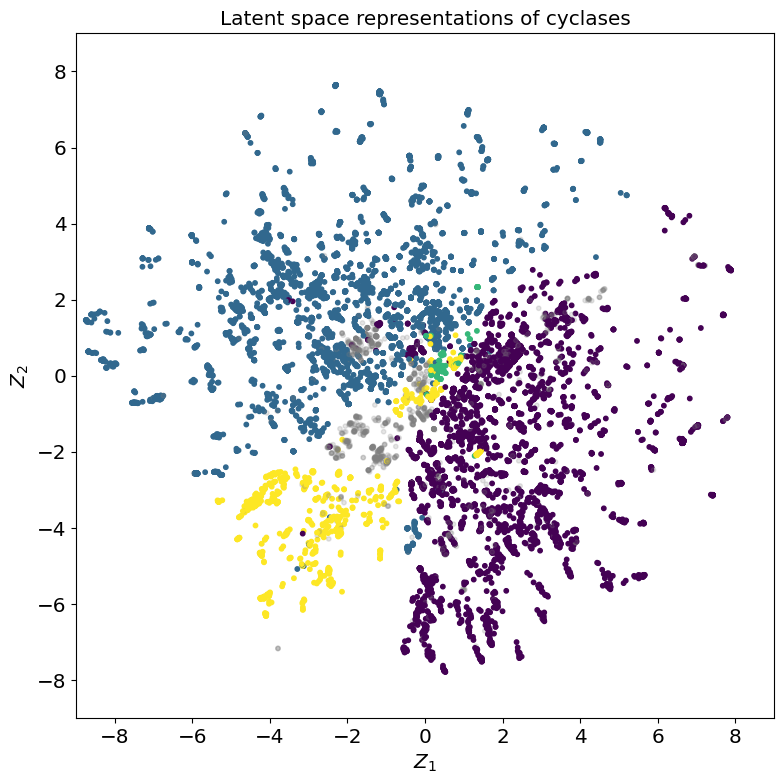

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import pickle
import numpy as np
from collections import Counter
from Bio import SeqIO
from matplotlib.lines import Line2D

# Make the format of images consistent
mpl.rc('font', size=12)
mpl.rc('axes', titlesize='large', labelsize='large')
mpl.rc('xtick', labelsize='large')
mpl.rc('ytick', labelsize='large')

# Model used
model_folder = "training_20260609_152220" # 2D

# Read latent space representation
with open(f"../models/{model_folder}/latent_space_fold_2.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)

key = data['key']
mu = data['mu']

# Function to parse FASTA files
def parse_fasta(file_path):
    with open(file_path, "r") as handle:
        return ['WP_' + record.id.split('_')[1] for record in SeqIO.parse(handle, "fasta")]

# Function to read CSV and filter by class
def csv2class(file, class_no):
    df = pd.read_csv(file)
    filtered_df = df[df['Classification'] == class_no]
    unique_ids_list = filtered_df['Query'].unique().tolist()
    return unique_ids_list

# Combine FASTA and CSV results
def get_combined_ids():
    fasta_files = {
        'Class I': '../data/processed/fasta/peptide/class_I-precursors_peptide.fasta',
        'Class II': '../data/processed/fasta/peptide/class_II-precursors_peptide.fasta',
        'Class III': '../data/processed/fasta/peptide/class_III-precursors_peptide.fasta',
        'Class IV': '../data/processed/fasta/peptide/class_IV-precursors_peptide.fasta',
    }
    co_occur_file = '../data/processed/rodeo/main_co_occur_all_classification_file.csv'

    class_I_ids = set(parse_fasta(fasta_files['Class I']) + csv2class(co_occur_file, 'class_I'))
    class_II_ids = set(parse_fasta(fasta_files['Class II']) + csv2class(co_occur_file, 'class_II'))
    class_III_ids = set(parse_fasta(fasta_files['Class III']) + csv2class(co_occur_file, 'class_III'))
    class_IV_ids = set(parse_fasta(fasta_files['Class IV']) + csv2class(co_occur_file, 'class_IV'))

    return class_I_ids, class_II_ids, class_III_ids, class_IV_ids

class_I_ids, class_II_ids, class_III_ids, class_IV_ids = get_combined_ids()

labels = []
unclassified_list = []
for k in key:
    k = k.split('/')[0]
    if k in class_I_ids:
        labels.append('Class I')
    elif k in class_II_ids:
        labels.append('Class II')
    elif k in class_III_ids:
        labels.append('Class III')
    elif k in class_IV_ids:
        labels.append('Class IV')
    else:
        labels.append('Unclassified')
        unclassified_list.append(k)

# Count the number of each class
label_counts = Counter(labels)
for label, count in label_counts.items():
    print(f"{label}: {count}")

# Creating a color map using plt's colormap
colormap = plt.cm.viridis  # choose any colormap that you like

# We exclude the first unique cluster (which should be 0) when generating colors
n_clusters = 4
n_colors = [colormap(i) for i in np.linspace(0, 1, n_clusters)]

color_map = {
    'Class I': n_colors[0],
    'Class II': n_colors[1],
    'Class III': n_colors[2],
    'Class IV': n_colors[3],
    'Unclassified': 'gray'
}

alpha_map = {
    'Class I': 1,
    'Class II': 1,
    'Class III': 1,
    'Class IV': 1,
    'Unclassified': 0.2
}

colors = [color_map[label] for label in labels]
alphas = [alpha_map[label] for label in labels]

plt.figure(figsize=(8, 8))
plt.scatter(mu[:, 0], mu[:, 1], c=colors, s=10, alpha=alphas)
plt.title('Latent space representations of cyclases')
plt.xlabel(r'$Z_1$')
plt.ylabel(r'$Z_2$')
plt.xlim((-9, 9))
plt.ylim((-9, 9))

# Hide the tick labels if needed
plt.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

# Create a legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label=key, markersize=10, markerfacecolor=value) for key, value in color_map.items()]
# plt.legend(handles=legend_elements, loc='best')

# Save plot to file if needed
plt.tight_layout()
plt.savefig('../results/Figure3/PF05147_latent_space.png', dpi=300, format='png')
plt.show()


#### Figure 3E. Functional classification results

Model: VAE_2D, Classifier: Logistic Regression - Accuracy: 0.968 ± 0.033, F1-score: 0.957 ± 0.044, MCC: 0.949 ± 0.049
Model: VAE_2D, Classifier: SVC - Accuracy: 0.968 ± 0.033, F1-score: 0.957 ± 0.044, MCC: 0.949 ± 0.049
Model: VAE_2D, Classifier: Naive Bayes - Accuracy: 0.982 ± 0.036, F1-score: 0.973 ± 0.053, MCC: 0.973 ± 0.053
Model: VAE_2D, Classifier: KNN - Accuracy: 1.000 ± 0.000, F1-score: 1.000 ± 0.000, MCC: 1.000 ± 0.000
Model: VAE_2D, Classifier: Decision Tree - Accuracy: 0.992 ± 0.015, F1-score: 0.992 ± 0.016, MCC: 0.988 ± 0.024
Model: VAE_2D, Classifier: Random Forest - Accuracy: 1.000 ± 0.000, F1-score: 1.000 ± 0.000, MCC: 1.000 ± 0.000
Model: VAE_3D, Classifier: Logistic Regression - Accuracy: 0.974 ± 0.036, F1-score: 0.975 ± 0.038, MCC: 0.963 ± 0.050
Model: VAE_3D, Classifier: SVC - Accuracy: 0.947 ± 0.088, F1-score: 0.935 ± 0.118, MCC: 0.925 ± 0.123
Model: VAE_3D, Classifier: Naive Bayes - Accuracy: 0.982 ± 0.036, F1-score: 0.973 ± 0.053, MCC: 0.973 ± 0.053
Model: VAE_3D,

/tmp/ipykernel_1599127/1291571211.py:220: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  viridis = cm.get_cmap('viridis')


Figure saved as ../results/Figure3/Results_Logistic_Regression_Class_IV_20260609.png


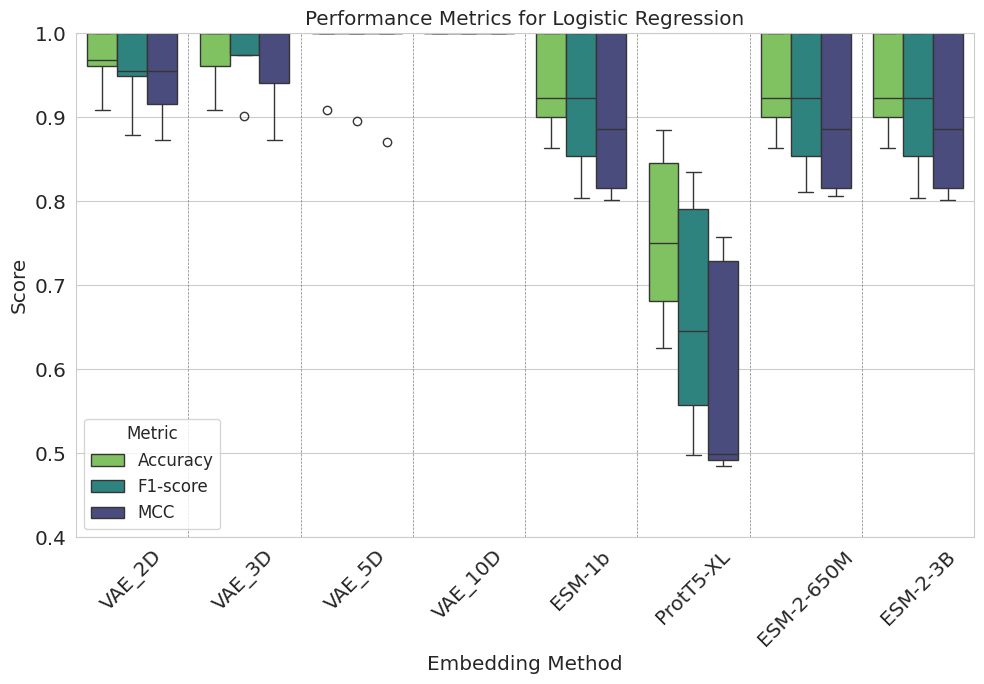

Figure saved as ../results/Figure3/Results_SVC_Class_IV_20260609.png


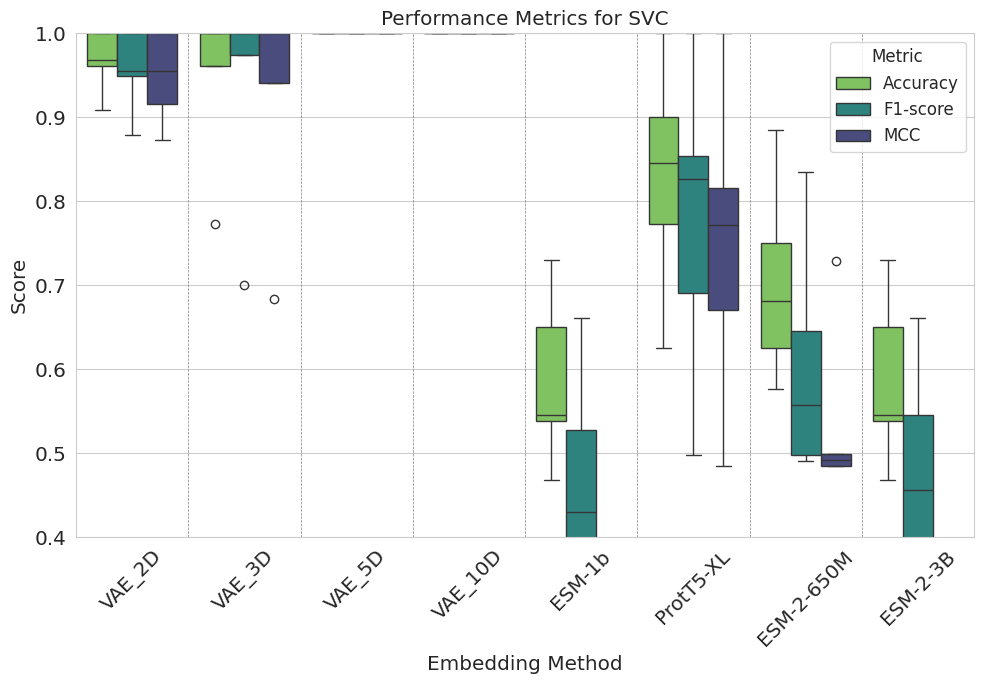

Figure saved as ../results/Figure3/Results_Naive_Bayes_Class_IV_20260609.png


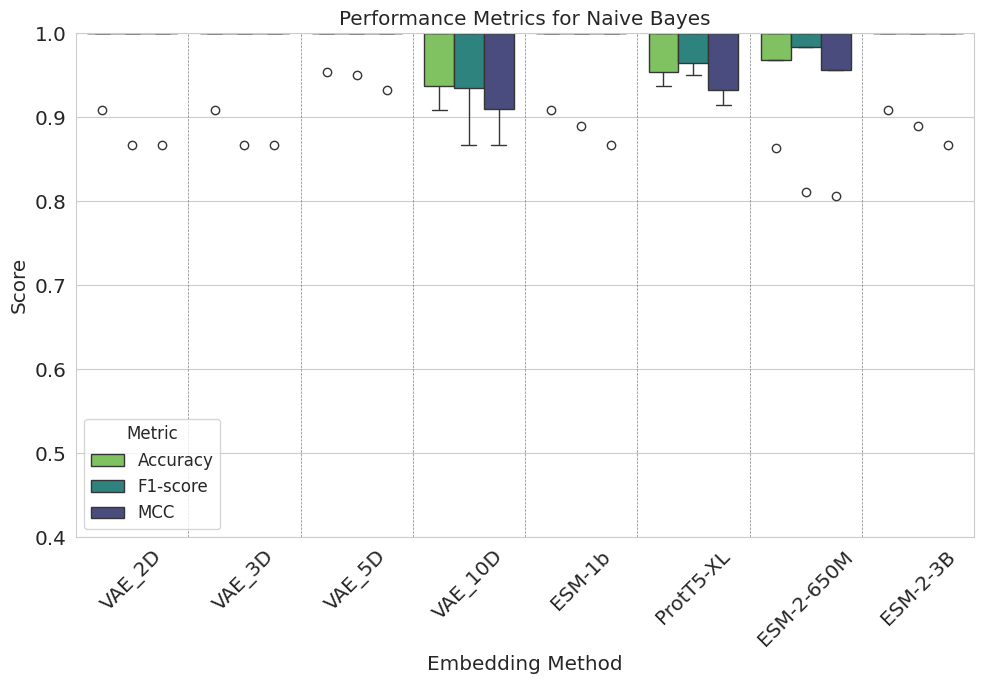

Figure saved as ../results/Figure3/Results_KNN_Class_IV_20260609.png


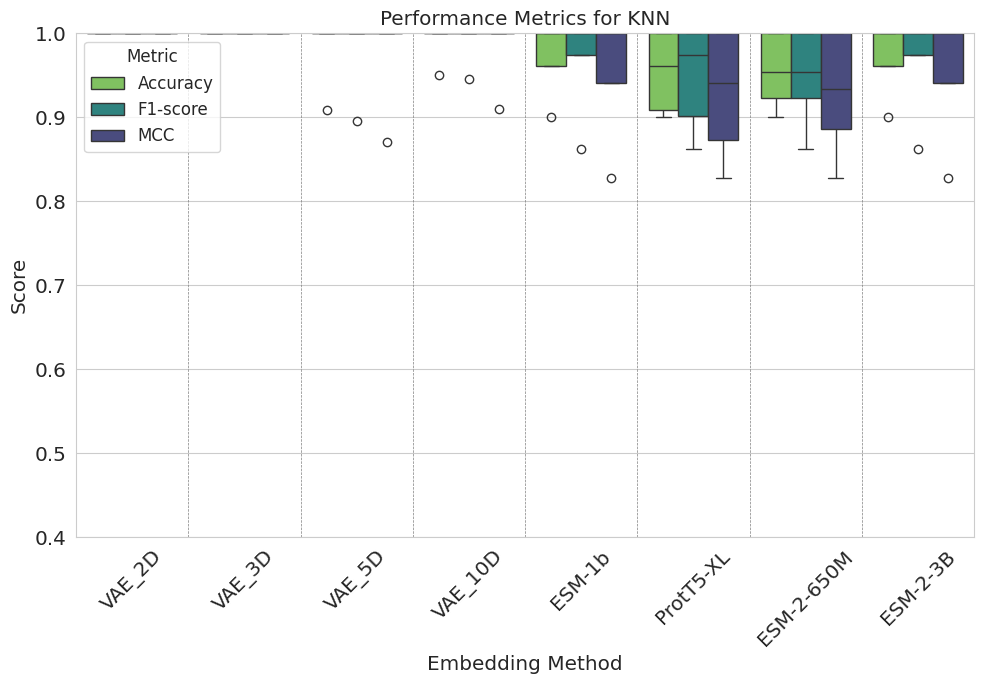

Figure saved as ../results/Figure3/Results_Decision_Tree_Class_IV_20260609.png


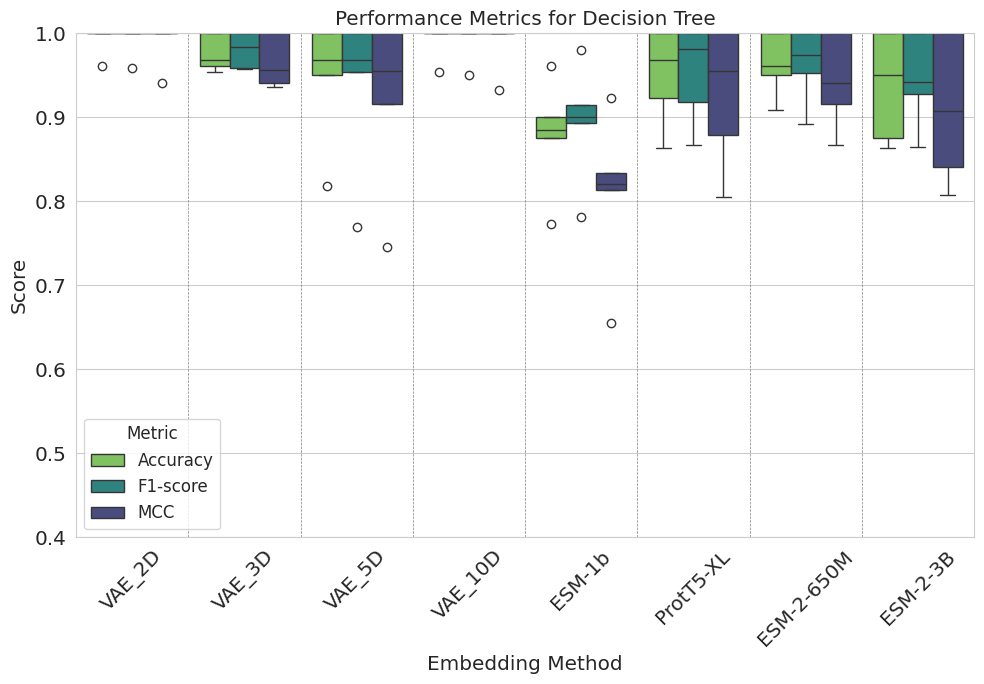

Figure saved as ../results/Figure3/Results_Random_Forest_Class_IV_20260609.png


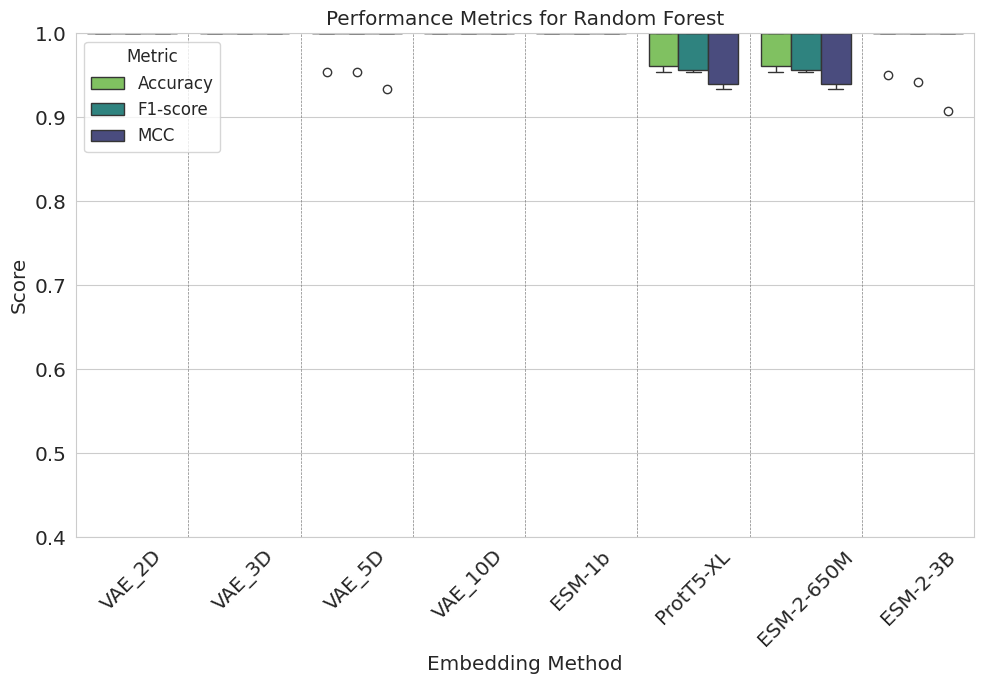

Results saved to ../results/Figure3/classification_results_summary_class_IV_20260609.xlsx.


In [2]:
import sys
sys.path.append("/home/cdchiang/vae/latent_space_paper")

import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from src.VAE_model import *

# Make the format of images consistent
mpl.rc('font', size=12)
mpl.rc('axes', titlesize='large', labelsize='large')
mpl.rc('xtick', labelsize='large')
mpl.rc('ytick', labelsize='large')

# VAE and other PLMs
model_dict = {
    'VAE_2D': "training_20260609_152220",
    'VAE_3D': "training_20260609_152739",
    'VAE_5D': "training_20260609_153257",
    'VAE_10D': "training_20260609_170534",
    'ProtT5-XL': "protein_embeddings.h5",
    'ESM-1b': "ESM1b_key2mu.pkl",
    'ESM-2-650M': "ESM2_650M_key2mu.pkl",
    'ESM-2-3B': "ESM2_3B_key2mu.pkl"
}

# Read embeddings from non VAE models
def read_embeddings(model_name):

    key2mu = {}
    model_path = model_dict[model_name]
    if model_name == "ProtT5-XL":
        with h5py.File(f'../models/{model_path}', 'r') as h5_file:
            keys = list(h5_file.keys())
            for key in keys:
                data = h5_file[key][:]
                new_key = key[:14]
                parts = new_key.split('_', 2)
                if len(parts) == 3:
                    new_key = parts[0] + '_' + parts[1] + '.' + parts[2]
                key2mu[new_key] = data

    # For models: "ESM-1b" or "ESM-2-650M" or "ESM-2-3B"
    else:
        with open(f"../models/{model_path}", 'rb') as f:
            key2mu = pickle.load(f)

    return key2mu

# Read SSN of RiPP precursor peptides
def read_ssn(ssn_file):
    df = pd.read_excel(ssn_file)
    id_list = df['name'].apply(lambda x: x[0:14]).tolist()
    cluster_list = df['Sequence Count Cluster Number']
    id_to_cluster_dict = {id: num for id, num in zip(id_list, cluster_list)}
    return id_to_cluster_dict

# Find the cyclases with functional labels
def data_prep(key2mu, data):
    common_keys = sorted(list(set(key2mu.keys()) & set(data.keys())))
    X = [key2mu[k] for k in common_keys]
    y = [data[k] for k in common_keys]
    # Output: mu, label, key
    return np.array(X), np.array(y), np.array(common_keys)

# Generate low-dimensional embeddings using VAE
def generate_vae_mu_for_fold(model, fold_idx, len_protein, num_res_type, dataloader):

    dim = int(model.split('_')[1].replace('D', ''))

    vae = VAE(num_aa_type = 21,
            dim_latent_vars = dim,
            dim_msa_vars = len_protein*num_res_type,
            encoder_num_hidden_units = [500, 100], 
            decoder_num_hidden_units = [100, 500])
    
    vae.load_state_dict(torch.load(f"../models/{model_dict[model]}/vae_fold_{fold_idx}.model", map_location='cpu'))
    vae.eval()

    # Transform the data to mu
    mu_list = []
    sigma_list = []
    key_list = []
    for idx, data in enumerate(dataloader):
        msa, weight, key = data
        with torch.no_grad():
            mu, sigma = vae.encoder(msa)
            mu_list.append(mu.cpu().data.numpy())
            sigma_list.append(sigma.cpu().data.numpy())
            key_list = key_list + list(key) # key is a tuple

    mu = np.vstack(mu_list)
    sigma = np.vstack(sigma_list)
    key2mu = {k.split('/')[0]: m for k, m in zip(key_list, mu)}

    return key2mu

# Classifiers to be trained
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "SVC": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

# Read SSN labels
RiPP_class = "IV" # Change the cyclase class (I, II, IV) you want to train the classifiers for.
ssn_file = f"../data/processed/ssn/peptide/class_{RiPP_class}-precursors_peptide_AS14_node_sorted.xlsx"
class_data = read_ssn(ssn_file)

# Read training and validation data
with open("../data/processed/training/cyclase/seq_msa_binary.pkl", 'rb') as file_handle:
    seq_msa_binary = pickle.load(file_handle)    
num_seq = seq_msa_binary.shape[0]
len_protein = seq_msa_binary.shape[1]
num_res_type = seq_msa_binary.shape[2]
seq_msa_binary = seq_msa_binary.reshape((num_seq, -1))
seq_msa_binary = seq_msa_binary.astype(np.float32)

with open("../data/processed/training/cyclase/seq_weight.pkl", 'rb') as file_handle:
    seq_weight = pickle.load(file_handle)
seq_weight = seq_weight.astype(np.float32)

with open("../data/processed/training/cyclase/keys_list.pkl", 'rb') as file_handle:
    seq_keys = pickle.load(file_handle)
seq_keys_short = [x.split('/')[0] for x in seq_keys]

# Load splits (splits are fixed for all VAE models)
splits_file = "../models/training_20260609_152220/kfold_splits.pkl"
with open(splits_file, 'rb') as f:
    idx_subset = pickle.load(f)

batch_size = num_seq
data = MSA_Dataset(seq_msa_binary, seq_weight, seq_keys)
dataloader = DataLoader(data, batch_size = batch_size)

representation_models = ['VAE_2D', 'VAE_3D', 'VAE_5D', 'VAE_10D', 'ESM-1b', 'ProtT5-XL', 'ESM-2-650M', 'ESM-2-3B']

all_results = []

for model in representation_models:

    if not model.startswith('VAE'):
        static_key2mu = read_embeddings(model)

    for classifier_name, classifier in classifiers.items():
        
        accuracy_scores, f1_scores, mcc_scores = [], [], []

        for fold_idx in range(5):
            
            # Get the right model for this fold
            if model.startswith('VAE'):
                # Generate mu using VAE_fold_k.model
                key2mu = generate_vae_mu_for_fold(model, fold_idx, len_protein, num_res_type, dataloader)
            else:
                # Reuse static ESM/ProtT5 features
                key2mu = static_key2mu
                
            X, y, current_keys = data_prep(key2mu, class_data)

            if X.size == 0 or y.size == 0:
                print(f"Skipping fold {fold_idx} due to empty X or y.")
                continue

            # Build the split indices
            validation_idx = idx_subset[fold_idx]
            validation_idx.sort()

            validation_keys = set([seq_keys_short[i] for i in validation_idx])
            test_idx = [i for i, key in enumerate(current_keys) if key in validation_keys]
            train_idx = [i for i, key in enumerate(current_keys) if key not in validation_keys]
            
            # Train and test the classifier
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            mcc = matthews_corrcoef(y_test, y_pred)
            
            accuracy_scores.append(acc)
            f1_scores.append(f1)
            mcc_scores.append(mcc)
            
            # Store for plotting
            all_results.extend([
                {"Classifier": classifier_name, "Embedding": model, "Metric": "Accuracy", "Score": acc},
                {"Classifier": classifier_name, "Embedding": model, "Metric": "F1-score", "Score": f1},
                {"Classifier": classifier_name, "Embedding": model, "Metric": "MCC", "Score": mcc}
            ])

        print(f"Model: {model}, Classifier: {classifier_name} - Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}, F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}, MCC: {np.mean(mcc_scores):.3f} ± {np.std(mcc_scores):.3f}")

# Convert all_results to a DataFrame
results_df = pd.DataFrame(all_results)

# Create a custom color palette using the viridis colormap
# We select positions in the colormap to get greenish to purplish colors
viridis = cm.get_cmap('viridis')
colors = [viridis(x) for x in [0.8, 0.5, 0.2]]  # Positions correspond to greenish to purplish
metrics = ['Accuracy', 'F1-score', 'MCC']
palette = dict(zip(metrics, colors))

# Plotting
for classifier_name in classifiers.keys():
    plt.figure(figsize=(10, 7))
    sns.set_style("whitegrid")

    # Filter results for the current classifier
    clf_results = results_df[results_df["Classifier"] == classifier_name]

    # Create a boxplot with the custom palette
    sns.boxplot(
        data=clf_results,
        x="Embedding",
        y="Score",
        hue="Metric",
        palette=palette
    )

    plt.title(f'Performance Metrics for {classifier_name}')
    plt.xlabel('Embedding Method')
    plt.ylabel('Score')
    plt.ylim(0.4, 1.0)
    plt.xticks(rotation=45)
    
    # Draw vertical lines to separate each embedding method
    num_embeddings = len(representation_models)
    for i in range(1, num_embeddings):
        plt.axvline(i - 0.5, color='gray', linestyle='--', linewidth=0.5)
    
    plt.tight_layout()

    # Save the figure
    filename = f'../results/Figure3/Results_{classifier_name.replace(" ", "_")}_Class_{RiPP_class}_20260609.png'
    plt.savefig(filename, dpi=300)
    print(f"Figure saved as {filename}")

    plt.show()

# Create a summary dataframe
summary_rows = []
for (model, classifier_name), group in results_df.groupby(["Embedding", "Classifier"]):
    for metric_name in ["Accuracy", "F1-score", "MCC"]:
        metric_scores = group[group["Metric"] == metric_name]["Score"]
        summary_rows.append({
            "Model": model,
            "Classifier": classifier_name,
            "Metric": metric_name,
            "Mean Score": metric_scores.mean(),
            "Std Score": metric_scores.std()
        })

summary_df = pd.DataFrame(summary_rows)
summary_file = f"../results/Figure3/classification_results_summary_class_{RiPP_class}_20260609.xlsx"
summary_df.to_excel(summary_file, index=False)
print(f"Results saved to {summary_file}.")

#### Figure 3E. Functional classification results (by metrics)

Model: VAE_2D, Classifier: Logistic Regression - Accuracy: 0.532 ± 0.035, F1-score: 0.447 ± 0.033, MCC: 0.512 ± 0.033
Model: VAE_2D, Classifier: SVC - Accuracy: 0.563 ± 0.029, F1-score: 0.498 ± 0.036, MCC: 0.548 ± 0.028
Model: VAE_2D, Classifier: Naive Bayes - Accuracy: 0.763 ± 0.024, F1-score: 0.753 ± 0.026, MCC: 0.754 ± 0.027
Model: VAE_2D, Classifier: KNN - Accuracy: 0.864 ± 0.028, F1-score: 0.858 ± 0.026, MCC: 0.858 ± 0.030
Model: VAE_2D, Classifier: Decision Tree - Accuracy: 0.897 ± 0.017, F1-score: 0.899 ± 0.021, MCC: 0.892 ± 0.017
Model: VAE_2D, Classifier: Random Forest - Accuracy: 0.917 ± 0.015, F1-score: 0.914 ± 0.017, MCC: 0.913 ± 0.015
Model: VAE_3D, Classifier: Logistic Regression - Accuracy: 0.660 ± 0.029, F1-score: 0.599 ± 0.032, MCC: 0.646 ± 0.029
Model: VAE_3D, Classifier: SVC - Accuracy: 0.683 ± 0.025, F1-score: 0.638 ± 0.026, MCC: 0.672 ± 0.025
Model: VAE_3D, Classifier: Naive Bayes - Accuracy: 0.804 ± 0.025, F1-score: 0.795 ± 0.021, MCC: 0.797 ± 0.027
Model: VAE_3D,

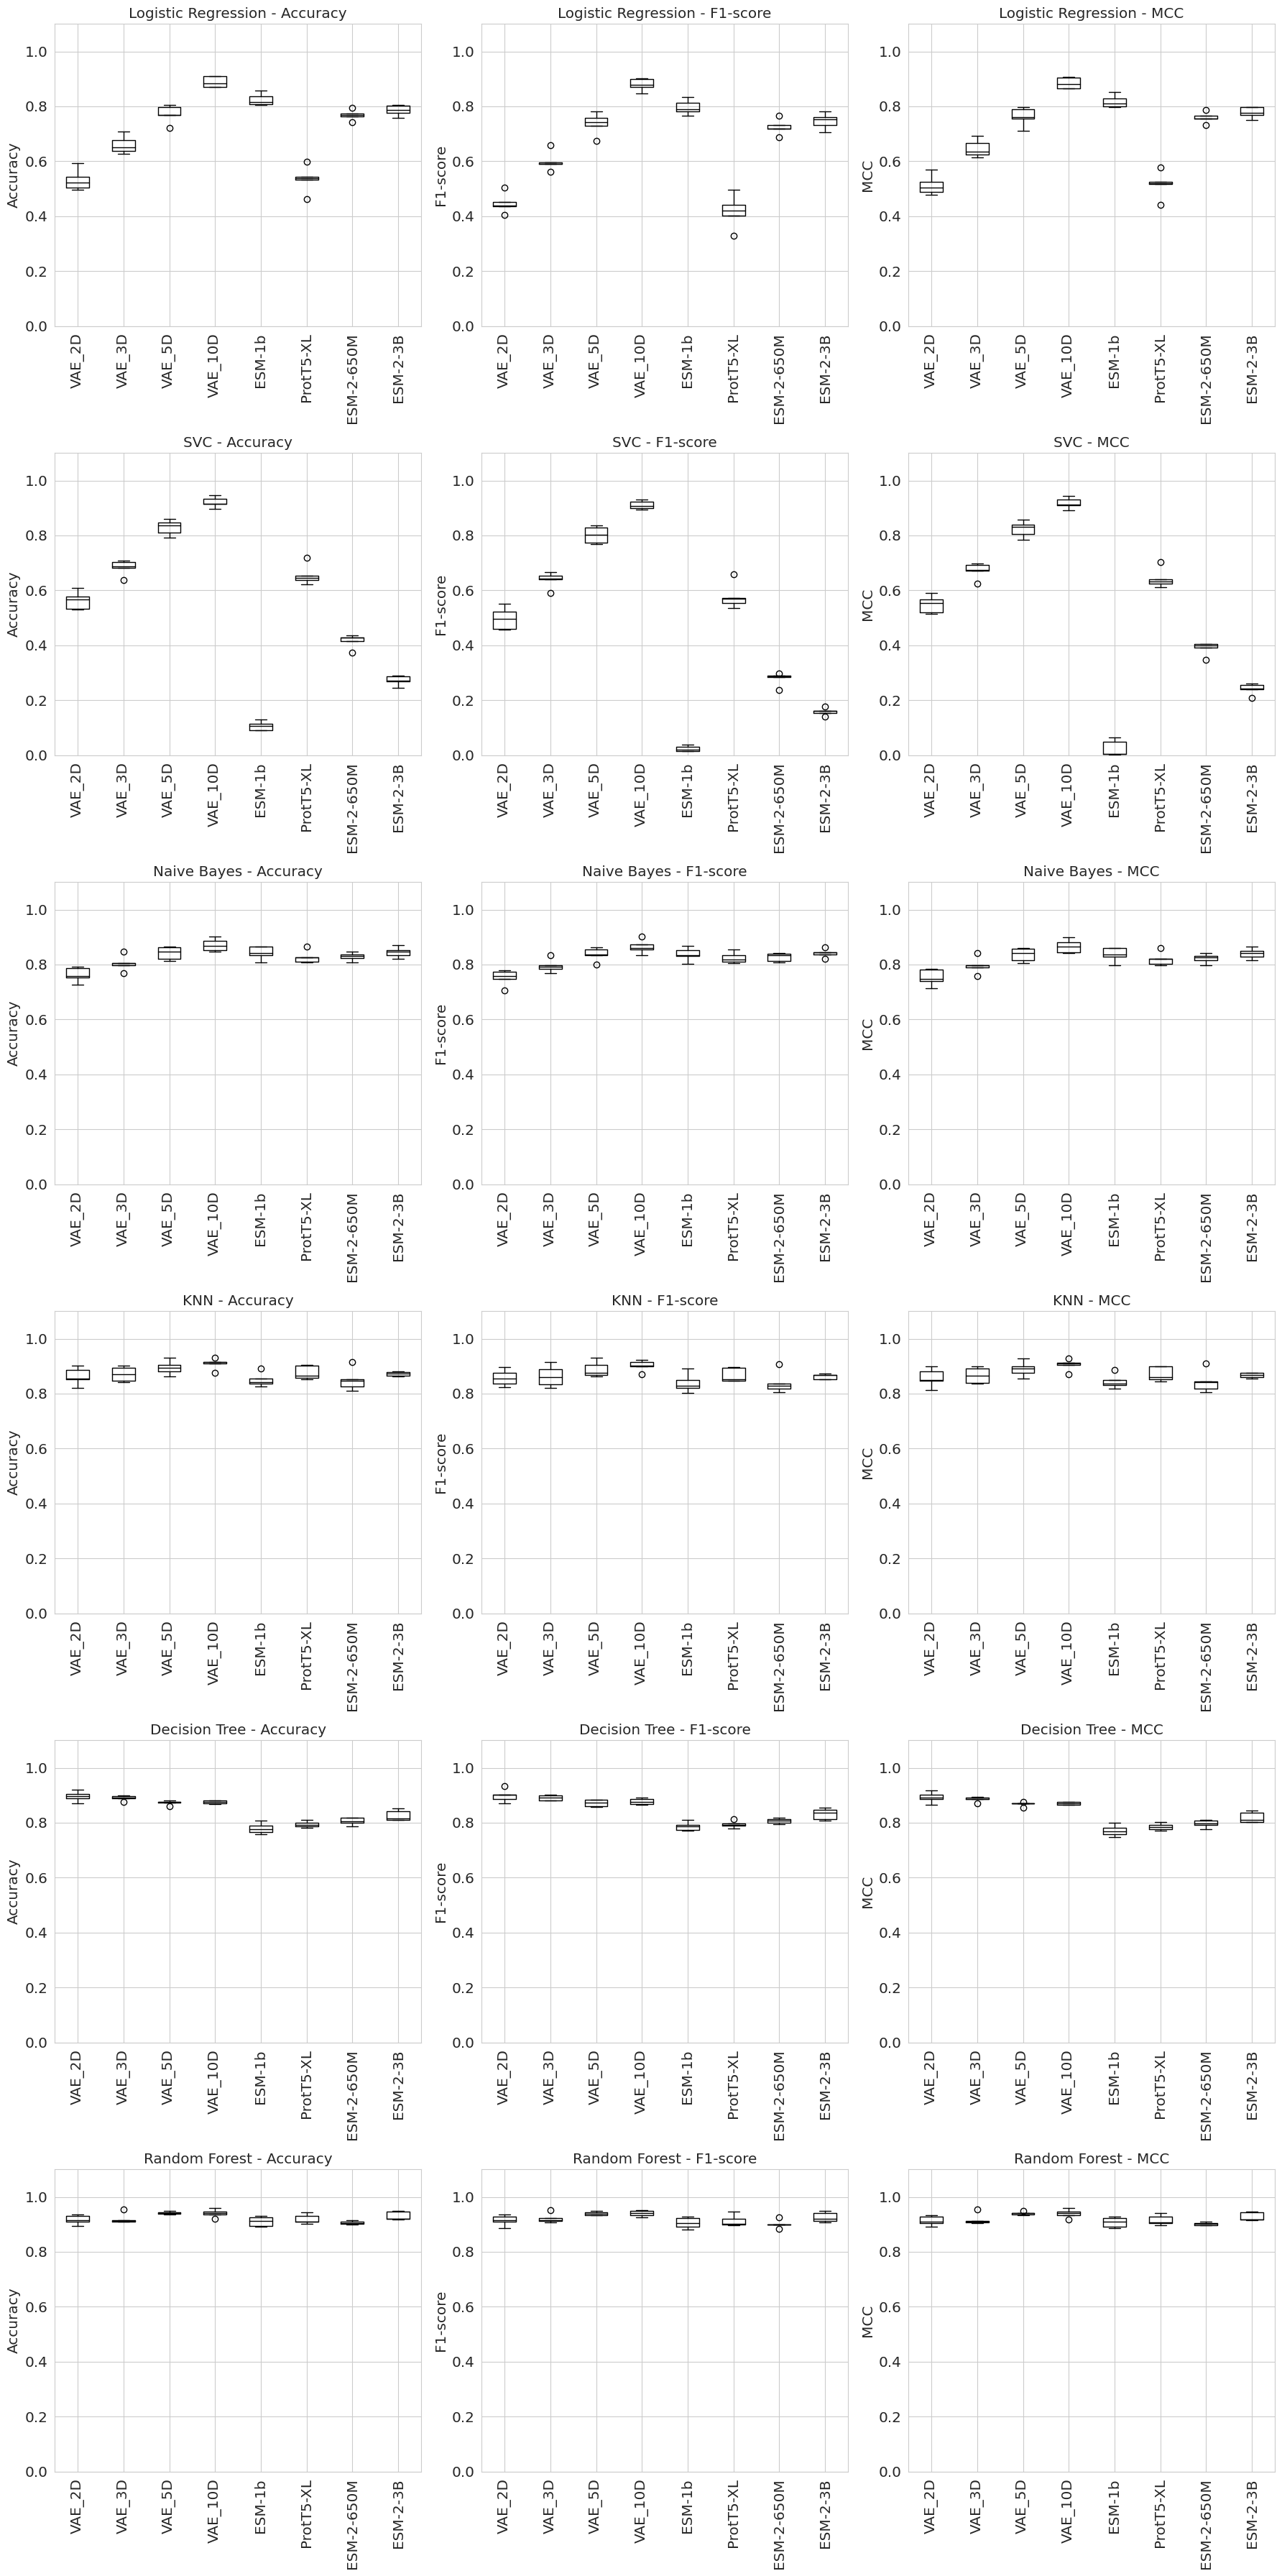

In [3]:
import sys
sys.path.append("/home/cdchiang/vae/latent_space_paper")

import pickle
import h5py
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef
from src.VAE_model import *

# Make the format of images consistent
mpl.rc('font', size=12)
mpl.rc('axes', titlesize='large', labelsize='large')
mpl.rc('xtick', labelsize='large')
mpl.rc('ytick', labelsize='large')

# VAE and other PLMs
model_dict = {
    'VAE_2D': "training_20260609_152220",
    'VAE_3D': "training_20260609_152739",
    'VAE_5D': "training_20260609_153257",
    'VAE_10D': "training_20260609_170534",
    'ProtT5-XL': "protein_embeddings.h5",
    'ESM-1b': "ESM1b_key2mu.pkl",
    'ESM-2-650M': "ESM2_650M_key2mu.pkl",
    'ESM-2-3B': "ESM2_3B_key2mu.pkl"
}

# Read embeddings from non VAE models
def read_embeddings(model_name):

    key2mu = {}
    model_path = model_dict[model_name]
    if model_name == "ProtT5-XL":
        with h5py.File(f'../models/{model_path}', 'r') as h5_file:
            keys = list(h5_file.keys())
            for key in keys:
                data = h5_file[key][:]
                new_key = key[:14]
                parts = new_key.split('_', 2)
                if len(parts) == 3:
                    new_key = parts[0] + '_' + parts[1] + '.' + parts[2]
                key2mu[new_key] = data

    # For models: "ESM-1b" or "ESM-2-650M" or "ESM-2-3B"
    else:
        with open(f"../models/{model_path}", 'rb') as f:
            key2mu = pickle.load(f)

    return key2mu

# Read SSN of RiPP precursor peptides
def read_ssn(ssn_file):
    df = pd.read_excel(ssn_file)
    id_list = df['name'].apply(lambda x: x[0:14]).tolist()
    cluster_list = df['Sequence Count Cluster Number']
    id_to_cluster_dict = {id: num for id, num in zip(id_list, cluster_list)}
    return id_to_cluster_dict

# Find the cyclases with functional labels
def data_prep(key2mu, data):
    common_keys = sorted(list(set(key2mu.keys()) & set(data.keys())))
    X = [key2mu[k] for k in common_keys]
    y = [data[k] for k in common_keys]
    # Output: mu, label, key
    return np.array(X), np.array(y), np.array(common_keys)

# Generate low-dimensional embeddings using VAE
def generate_vae_mu_for_fold(model, fold_idx, len_protein, num_res_type, dataloader):

    dim = int(model.split('_')[1].replace('D', ''))

    vae = VAE(num_aa_type = 21,
            dim_latent_vars = dim,
            dim_msa_vars = len_protein*num_res_type,
            encoder_num_hidden_units = [500, 100], 
            decoder_num_hidden_units = [100, 500])
    
    vae.load_state_dict(torch.load(f"../models/{model_dict[model]}/vae_fold_{fold_idx}.model", map_location='cpu'))
    vae.eval()

    # Transform the data to mu
    mu_list = []
    sigma_list = []
    key_list = []
    for idx, data in enumerate(dataloader):
        msa, weight, key = data
        with torch.no_grad():
            mu, sigma = vae.encoder(msa)
            mu_list.append(mu.cpu().data.numpy())
            sigma_list.append(sigma.cpu().data.numpy())
            key_list = key_list + list(key) # key is a tuple

    mu = np.vstack(mu_list)
    sigma = np.vstack(sigma_list)
    key2mu = {k.split('/')[0]: m for k, m in zip(key_list, mu)}

    return key2mu

# Classifiers to be trained
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "SVC": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
}

# Read SSN labels
RiPP_class = "II" # Change the cyclase class (I, II, IV) you want to train the classifiers for.
ssn_file = f"../data/processed/ssn/peptide/class_{RiPP_class}-precursors_peptide_AS14_node_sorted.xlsx"
class_data = read_ssn(ssn_file)

# Read training and validation data
with open("../data/processed/training/cyclase/seq_msa_binary.pkl", 'rb') as file_handle:
    seq_msa_binary = pickle.load(file_handle)    
num_seq = seq_msa_binary.shape[0]
len_protein = seq_msa_binary.shape[1]
num_res_type = seq_msa_binary.shape[2]
seq_msa_binary = seq_msa_binary.reshape((num_seq, -1))
seq_msa_binary = seq_msa_binary.astype(np.float32)

with open("../data/processed/training/cyclase/seq_weight.pkl", 'rb') as file_handle:
    seq_weight = pickle.load(file_handle)
seq_weight = seq_weight.astype(np.float32)

with open("../data/processed/training/cyclase/keys_list.pkl", 'rb') as file_handle:
    seq_keys = pickle.load(file_handle)
seq_keys_short = [x.split('/')[0] for x in seq_keys]

# Load splits (splits are fixed for all VAE models)
splits_file = "../models/training_20260609_152220/kfold_splits.pkl"
with open(splits_file, 'rb') as f:
    idx_subset = pickle.load(f)

batch_size = num_seq
data = MSA_Dataset(seq_msa_binary, seq_weight, seq_keys)
dataloader = DataLoader(data, batch_size = batch_size)

representation_models = ['VAE_2D', 'VAE_3D', 'VAE_5D', 'VAE_10D', 'ESM-1b', 'ProtT5-XL', 'ESM-2-650M', 'ESM-2-3B']

results = {model: {clf: {"Accuracy": [], "F1-score": [], "MCC": []} for clf in classifiers} for model in representation_models}

for model in representation_models:

    if not model.startswith('VAE'):
        static_key2mu = read_embeddings(model)

    for classifier_name, classifier in classifiers.items():
        
        accuracy_scores, f1_scores, mcc_scores = [], [], []

        for fold_idx in range(5):
            
            # Get the right model for this fold
            if model.startswith('VAE'):
                # Generate mu using VAE_fold_k.model
                key2mu = generate_vae_mu_for_fold(model, fold_idx, len_protein, num_res_type, dataloader)
            else:
                # Reuse static ESM/ProtT5 features
                key2mu = static_key2mu
                
            X, y, current_keys = data_prep(key2mu, class_data)

            if X.size == 0 or y.size == 0:
                print(f"Skipping fold {fold_idx} due to empty X or y.")
                continue

            # Build the split indices
            validation_idx = idx_subset[fold_idx]
            validation_idx.sort()

            validation_keys = set([seq_keys_short[i] for i in validation_idx])
            test_idx = [i for i, key in enumerate(current_keys) if key in validation_keys]
            train_idx = [i for i, key in enumerate(current_keys) if key not in validation_keys]
            
            # Train and test the classifier
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            classifier.fit(X_train, y_train)
            y_pred = classifier.predict(X_test)
            
            # Calculate metrics
            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='weighted')
            mcc = matthews_corrcoef(y_test, y_pred)
            
            accuracy_scores.append(acc)
            f1_scores.append(f1)
            mcc_scores.append(mcc)

        results[model][classifier_name]["Accuracy"] = accuracy_scores
        results[model][classifier_name]["F1-score"] = f1_scores
        results[model][classifier_name]["MCC"] = mcc_scores

        print(f"Model: {model}, Classifier: {classifier_name} - Accuracy: {np.mean(accuracy_scores):.3f} ± {np.std(accuracy_scores):.3f}, F1-score: {np.mean(f1_scores):.3f} ± {np.std(f1_scores):.3f}, MCC: {np.mean(mcc_scores):.3f} ± {np.std(mcc_scores):.3f}")

# Plot boxplots for each metric
plt.figure(figsize=(18, 36))
yticks = np.arange(0, 1.2, 0.2)

for i, classifier_name in enumerate(classifiers.keys()):
    for j, metric_name in enumerate(["Accuracy", "F1-score", "MCC"]):
        plt.subplot(6, 3, i*3 + j + 1)
        data_to_plot = [results[model][classifier_name][metric_name] for model in representation_models]
        box = plt.boxplot(data_to_plot, labels=representation_models, patch_artist=False)
        for median in box['medians']:
            median.set(color='black')
        plt.title(f'{classifier_name} - {metric_name}')
        plt.xticks(rotation=90)
        plt.ylabel(metric_name)
        plt.yticks(yticks)
        plt.ylim(0, 1.1)

plt.tight_layout()
plt.savefig(f'../results/Figure3/Representation_Model_Comparison_Class_{RiPP_class}_Metrics_20260609.png', dpi=300, format='png')
plt.show()

# Save results to Excel file
results_summary = []

for model in representation_models:
    for classifier_name in classifiers.keys():
        accuracy_scores = results[model][classifier_name]["Accuracy"]
        f1_scores = results[model][classifier_name]["F1-score"]
        mcc_scores = results[model][classifier_name]["MCC"]
        
        results_summary.append({
            "Model": model,
            "Classifier": classifier_name,
            "Accuracy Mean": np.mean(accuracy_scores),
            "Accuracy Std": np.std(accuracy_scores),
            "F1-score Mean": np.mean(f1_scores),
            "F1-score Std": np.std(f1_scores),
            "MCC Mean": np.mean(mcc_scores),
            "MCC Std": np.std(mcc_scores)
        })

results_df = pd.DataFrame(results_summary)
results_df.to_excel(f"../results/Figure3/classification_results_summary_class_{RiPP_class}_metrics_20260609.xlsx", index=False)

#### Figure 3F. Clustering agreement evaluated by adjusted mutual information (AMI) between:
(1) Clustering of **RiPPs peptide precursors by SSN**
(2) Clustering of **LanC-like cyclases in the 2D latent space** 

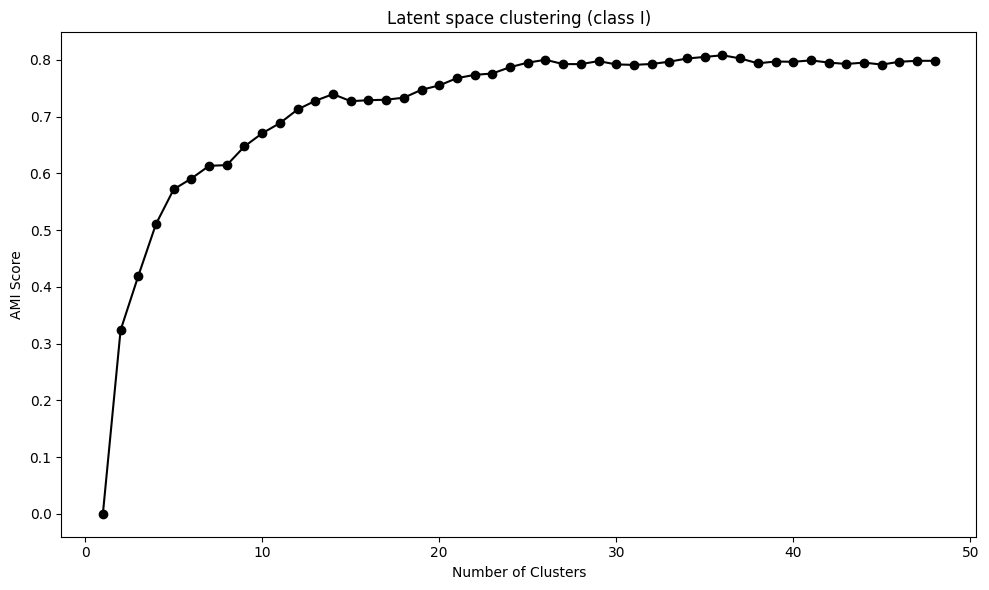

Highest AMI score from the latent space clustering:  0.808061167474953
SSN_AS46_Cluster_No:  8
SSN_AS46 AMI score:  0.3053446080109746
SSN_AS52_Cluster_No:  13
SSN_AS52 AMI score:  0.3311858382228783
SSN_AS66_Cluster_No:  28
SSN_AS66 AMI score:  0.6914732228726799
SSN_AS80_Cluster_No:  38
SSN_AS80 AMI score:  0.7682558762652643


In [21]:
import matplotlib as mpl
import math
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
import seaborn as sns
from Bio import SeqIO
from sys import exit
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.cluster import adjusted_mutual_info_score

# Make the format of images consistent
mpl.rc('font', size = 12)
mpl.rc('axes', titlesize = 'large', labelsize = 'large')
mpl.rc('xtick', labelsize = 'large')
mpl.rc('ytick', labelsize = 'large')

# Read latent space representation
model_folder = "training_20260609_152220" # model directory
with open("../models/{}/latent_space_fold_2.pkl".format(model_folder), 'rb') as file_handle:
    data = pickle.load(file_handle)
key = data['key']
mu = data['mu']
key2mu = {k[0:14]: m for k, m in zip(key, mu)}

# Read the SSN clustering of cyclases (alignment score: 46)
enzyme_ssn_file_AS46 = "../data/processed/ssn/cyclase/PF05147_hits_200_500aa_latentspace_AS46 Full Network colorized default node.csv"
df_enzyme_46 = pd.read_csv(enzyme_ssn_file_AS46)
enzyme_id_list_46 = df_enzyme_46['name'].apply(lambda x: x[0:14]).tolist()
enzyme_cluster_list_46 = df_enzyme_46['Node Count Cluster Number']
key2ssn_46 = {id: cluster_no for id, cluster_no in zip(enzyme_id_list_46, enzyme_cluster_list_46)}

# Read the SSN clustering of cyclases (alignment score: 52)
enzyme_ssn_file_AS52 = "../data/processed/ssn/cyclase/PF05147_hits_200_500aa_latentspace_AS52 Full Network colorized default node.csv"
df_enzyme_52 = pd.read_csv(enzyme_ssn_file_AS52)
enzyme_id_list_52 = df_enzyme_52['name'].apply(lambda x: x[0:14]).tolist()
enzyme_cluster_list_52 = df_enzyme_52['Node Count Cluster Number']
key2ssn_52 = {id: cluster_no for id, cluster_no in zip(enzyme_id_list_52, enzyme_cluster_list_52)}

# Read the SSN clustering of cyclases (alignment score: 66)
enzyme_ssn_file_AS66 = "../data/processed/ssn/cyclase/PF05147_hits_200_500aa_latentspace_AS66 Full Network colorized default node.csv"
df_enzyme_66 = pd.read_csv(enzyme_ssn_file_AS66)
enzyme_id_list_66 = df_enzyme_66['name'].apply(lambda x: x[0:14]).tolist()
enzyme_cluster_list_66 = df_enzyme_66['Node Count Cluster Number']
key2ssn_66 = {id: cluster_no for id, cluster_no in zip(enzyme_id_list_66, enzyme_cluster_list_66)}

# Read the SSN clustering of cyclases (alignment score: 80)

enzyme_ssn_file_AS80 = "../data/processed/ssn/cyclase/PF05147_hits_200_500aa_latentspace_AS80 Full Network colorized default node.csv"
df_enzyme_80 = pd.read_csv(enzyme_ssn_file_AS80)
enzyme_id_list_80 = df_enzyme_80['name'].apply(lambda x: x[0:14]).tolist()
enzyme_cluster_list_80 = df_enzyme_80['Node Count Cluster Number']
key2ssn_80 = {id: cluster_no for id, cluster_no in zip(enzyme_id_list_80, enzyme_cluster_list_80)}

# Read the SSN clustering of lanthipeptide precursors

def ssn_analyzer(file):

    df = pd.read_excel(file)
    # id_list = df['name'].apply(lambda x: x[0:14]).tolist()
    id_list = df['Description'].apply(lambda x: x[0:14]).tolist()
    cluster_list = df['Node Count Cluster Number']
    id_to_cluster_dict = {id: cluster_no for id, cluster_no in zip(id_list, cluster_list)}

    return id_to_cluster_dict

# SSN files of the lanthipeptide precursors (I, II, and IV)
RiPP_class = "I" # I or II or IV
ssn_file = f"../data/processed/ssn/peptide/class_{RiPP_class}-precursors_peptide_AS14_node_sorted.xlsx"

id_to_cluster_dict = ssn_analyzer(ssn_file)

labels_true = []
ssn_label_46 = []
ssn_label_52 = []
ssn_label_66 = []
ssn_label_80 = []
mu_values = []
for id in id_to_cluster_dict.keys():
    if id in key2ssn_46 and id in key2ssn_52 and key2ssn_66 and key2ssn_80 and id in key2mu:
        if not math.isnan(key2ssn_46[id]) and not math.isnan(key2ssn_52[id]) and not math.isnan(key2ssn_66[id]) and not math.isnan(key2ssn_80[id]):
            labels_true.append(id_to_cluster_dict[id])
            ssn_label_46.append(key2ssn_46[id])
            ssn_label_52.append(key2ssn_52[id])
            ssn_label_66.append(key2ssn_66[id])
            ssn_label_80.append(key2ssn_80[id])
            mu_values.append(key2mu[id])

# Convert the list of mu values to a NumPy array
mu_array = np.array(mu_values)

# Adjusted mutual information (AMI) calculation
AMI_score = []
unique_clusters = len(set(id_to_cluster_dict.values()))
for n in range(1, unique_clusters + 1):
    clustering = AgglomerativeClustering(n_clusters=n).fit(mu_array)
    ami = adjusted_mutual_info_score(labels_true, clustering.labels_)
    AMI_score.append(ami)

# Create a DataFrame with the results
df = pd.DataFrame({
    "Number of clusters": list(range(1, unique_clusters + 1)),
    "AMI scores": AMI_score
})

# Save the DataFrame to an Excel file
df.to_excel(f"../results/Figure3/AMI_scores_latentspace_clustering_class{RiPP_class}.xlsx", index=False)

# Plotting
num_clusters_list = [n for n in range(1, unique_clusters + 1)]

# Setting a white background for the plot
plt.style.use('default')
plt.figure(figsize=(10, 6), facecolor='white')
plt.plot(num_clusters_list, AMI_score, marker='o', color='black')
plt.xlabel('Number of Clusters')
plt.ylabel('AMI Score')
plt.title(f'Latent space clustering (class {RiPP_class})')
plt.tight_layout()
plt.savefig(f'../results/Figure3/AMI_latentspace_clustering_class{RiPP_class}.png', dpi=300, format='png')
plt.show()

# Print
print('Highest AMI score from the latent space clustering: ', max(AMI_score))
print('SSN_AS46_Cluster_No: ', len(set(ssn_label_46)))
print('SSN_AS46 AMI score: ', adjusted_mutual_info_score(labels_true, ssn_label_46))
print('SSN_AS52_Cluster_No: ', len(set(ssn_label_52)))
print('SSN_AS52 AMI score: ', adjusted_mutual_info_score(labels_true, ssn_label_52))
print('SSN_AS66_Cluster_No: ', len(set(ssn_label_66)))
print('SSN_AS66 AMI score: ', adjusted_mutual_info_score(labels_true, ssn_label_66))
print('SSN_AS80_Cluster_No: ', len(set(ssn_label_80)))
print('SSN_AS80 AMI score: ', adjusted_mutual_info_score(labels_true, ssn_label_80))


#### Figure 3G. Navigate the function space (peptide substrate cluster distribution)

/tmp/ipykernel_1209175/3976574253.py:154: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


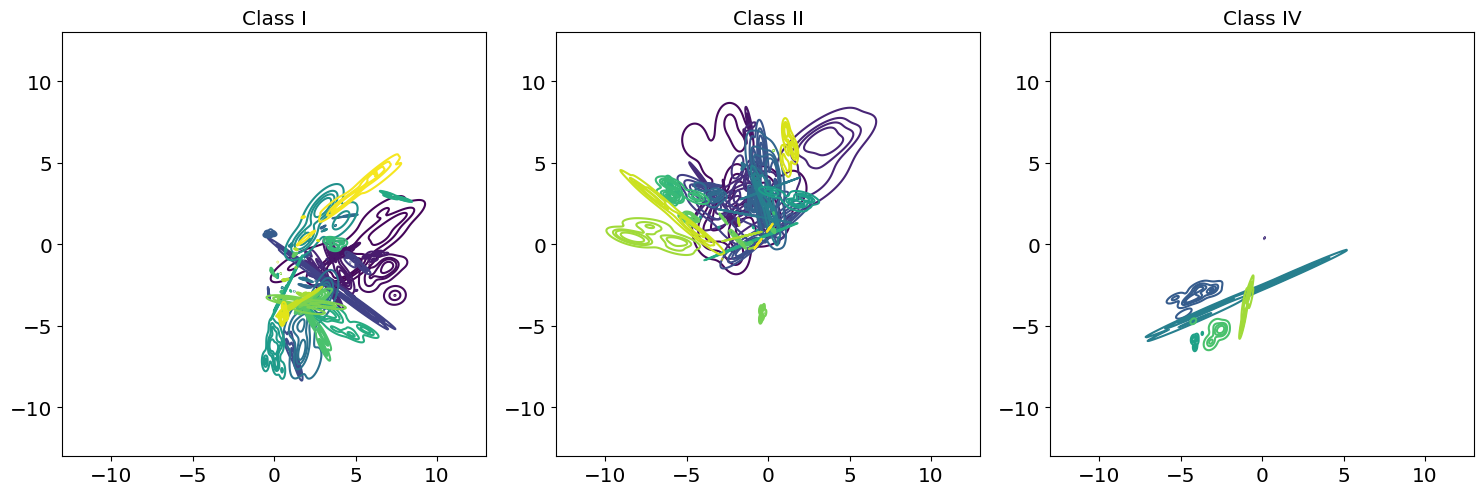

In [3]:
import matplotlib as mpl
# Non-interactive but high-quality image files
# mpl.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.autograd import Variable
import numpy as np
import pickle
import torch
import pandas as pd
import seaborn as sns
from Bio import SeqIO
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sys import exit
from torch.utils.data import Dataset, DataLoader

# Make the format of images consistent
mpl.rc('font', size=12)
mpl.rc('axes', titlesize='large', labelsize='large')
mpl.rc('xtick', labelsize='large')
mpl.rc('ytick', labelsize='large')

model_folder = "training_20260609_152220" # model directory

# Read latent space representation
with open(f"../models/{model_folder}/latent_space_fold_2.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)
key = data['key']
mu = data['mu']

# Read FASTA file
def parse_fasta(file_path):
    with open(file_path, "r") as handle:
        return ['WP_' + record.id.split('_')[1] for record in SeqIO.parse(handle, "fasta")]

# Data from the paper
class_I_ids = parse_fasta('../data/processed/fasta/peptide/class_I-precursors_peptide.fasta')
class_II_ids = parse_fasta('../data/processed/fasta/peptide/class_II-precursors_peptide.fasta')
class_III_ids = parse_fasta('../data/processed/fasta/peptide/class_III-precursors_peptide.fasta')
class_IV_ids = parse_fasta('../data/processed/fasta/peptide/class_IV-precursors_peptide.fasta')

# Read CSV as a DataFrame
def csv2class(file, class_no):
    df = pd.read_csv(file)
    filtered_df = df[df['Classification'] == class_no]
    unique_ids_list = filtered_df['Query'].unique().tolist()
    return unique_ids_list

# Data from the RODEO prediction
co_occur_file = '../data/processed/rodeo/main_co_occur_all_classification_file.csv'
class_I_ids_u = csv2class(co_occur_file, 'class_I')
class_II_ids_u = csv2class(co_occur_file, 'class_II')
class_III_ids_u = csv2class(co_occur_file, 'class_III')
class_IV_ids_u = csv2class(co_occur_file, 'class_IV')

# Assign classes to IDs
id2class = {}
for k in key:
    k = k.split('/')[0]
    if k in class_I_ids or k in class_I_ids_u:
        id2class[k] = 1
    elif k in class_II_ids or k in class_II_ids_u:
        id2class[k] = 2
    elif k in class_III_ids or k in class_III_ids_u:
        id2class[k] = 3
    elif k in class_IV_ids or k in class_IV_ids_u:
        id2class[k] = 4
    else:
        id2class[k] = 0

excel_file = '../data/raw/cyclase/12864_2020_6785_MOESM2_ESM.xlsx'
excel_file2 = '../data/processed/rodeo/main_co_occur_all_classification_file.csv'

sheet_names = ['class_I-precursors', 'class_II-precursors', 'class_III-precursors', 'class_IV-precursors']

# Combine data from different sheets into id2genus
id2genus = {}
for sheet_name in sheet_names:
    try:
        df = pd.read_excel(excel_file, sheet_name=sheet_name)
        df['genus/species'] = df['genus/species'].apply(lambda x: x.split(' ')[0])
        df['Precursor SSN ID'] = df['Precursor SSN ID'].apply(lambda x: x[:14])
        id2genus.update(df.set_index('Precursor SSN ID')['genus/species'].to_dict())
    except Exception as e:
        print(f"Error reading sheet {sheet_name}: {e}")

# Read another CSV file and combine its data
try:
    df2 = pd.read_csv(excel_file2)
    df2_unique = df2.drop_duplicates(subset='Query').copy()
    df2_unique['Genus/Species'] = df2_unique['Genus/Species'].apply(lambda x: x.split(' ')[0])
    id2genus.update(df2_unique.set_index('Query')['Genus/Species'].to_dict())
except Exception as e:
    print(f"Error reading file: {e}")

# Load the genus_to_phylum dictionary from the file
with open('../data/processed/random/genus_to_phylum.pkl', 'rb') as f:
    genus_to_phylum = pickle.load(f)

# Map phylum to each enzyme ID
id2phylum = {enzyme_id: genus_to_phylum.get(genus, "Unknown") for enzyme_id, genus in id2genus.items()}

# Load the lanthipeptide data and the clustering info
id2peptide = {}
id2peptide_cluster = {}
for i in ["I", "II", "III", "IV"]:
    df3 = pd.read_excel(f"../data/processed/ssn/peptide/class_{i}-precursors_peptide_c_u_AS14 Full Network colorized default node_sorted_unique.xlsx")
    df3['Node Count Cluster Number'] = i + '-' + df3['Node Count Cluster Number'].astype(str)
    df3['name'] = df3['name'].str.slice(0, 14)
    id2peptide.update(df3.set_index('name')['Sequence'].to_dict())
    id2peptide_cluster.update(df3.set_index('name')['Node Count Cluster Number'].to_dict())

latent_space_data = {
    'Cyclase_id': [n[:14] for n in key],
    'Z1': mu[:, 0],
    'Z2': mu[:, 1],
    'Class': [id2class[n[:14]] for n in key]
}

df_latent_space = pd.DataFrame(latent_space_data)

# Map phylum to each enzyme ID in the DataFrame
df_latent_space['Phylum'] = df_latent_space['Cyclase_id'].map(id2phylum)

# Map peptide sequence and cluster number to each enzyme ID in the DataFrame
df_latent_space['Peptide'] = df_latent_space['Cyclase_id'].map(lambda x: id2peptide.get(x, 'Unknown'))
df_latent_space['Cluster No'] = df_latent_space['Cyclase_id'].map(lambda x: id2peptide_cluster.get(x, 'Unknown'))

df_latent_space.to_excel('../results/Figure3/lanthipeptide_cyclase_latentspace_summary.xlsx', sheet_name='sheet1')

# Plotting
fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1 row, 3 columns

# Define big clusters to include only I, II, and IV
big_clusters = ['I', 'II', 'IV']
class_mapping = {'I': 1, 'II': 2, 'III': 3, 'IV': 4}

# Iterate over big clusters and subplots
for i, big_cluster in enumerate(big_clusters):
    ax = axs[i]
    class_number = class_mapping[big_cluster]
    big_cluster_df = df_latent_space[
        (df_latent_space['Class'] == class_number) & (df_latent_space['Peptide'] != 'Unknown')
    ]
    small_clusters = big_cluster_df['Cluster No'].unique()

    # Define a color palette with enough colors for all small clusters
    palette = sns.color_palette("viridis", len(small_clusters))

    # Iterate over small clusters within each big cluster
    for j, small_cluster in enumerate(small_clusters):
        small_cluster_df = big_cluster_df[big_cluster_df['Cluster No'] == small_cluster]
        sns.kdeplot(
            x=small_cluster_df['Z1'],
            y=small_cluster_df['Z2'],
            levels=5,
            ax=ax,
            label=small_cluster,
            color=palette[j],
            legend=False
        )

    ax.set_title(f'Class {big_cluster}')
    # Hide x and y labels but keep ticks
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(
        axis='both',
        which='both',
        bottom=True,
        top=False,
        left=True,
        right=False,
        labelbottom=True,
        labelleft=True
    )
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-13, 13)
    ax.set_ylim(-13, 13)

plt.tight_layout()
plt.savefig('../results/Figure3/Fig3G_peptide_substrate_cluster_distribution.png', dpi= 300, format='png')
plt.show()

